# Query Diversity Analysis

In [2]:
import pandas as pd
import lark
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from collections import defaultdict

# Load both CSVs
df_rel = pd.read_csv('imdb_adversarial_relative.csv')
df_abs = pd.read_csv('imdb_adversarial_absolute.csv')

# Grammar for parsing queries
parsing_grammar = """

start: selector+
selector: "(" ident " " filter* ")"
?ident: /[a-z0-9_]+/
filter: int_filter | str_filter
int_filter: "(" ident " " intop " " intval ")"
str_filter: "(" ident " " strop ")"

!intop: "<" | ">" | "=" | "!="
!strop: "most_popular" | "random"

!intval: "first" | "median" | "last" | "mode" | /[0-9]{4}/
"""
g = lark.Lark(parsing_grammar)

print(f"Loaded {len(df_rel)} relative queries and {len(df_abs)} absolute queries")

# Helper function to parse queries and extract table counts
def get_table_counts(df_data, parser):
    table_counts = []
    for query_str in df_data['query']:
        try:
            t = parser.parse(query_str)
            num_tables = len(t.children)
            table_counts.append(num_tables)
        except Exception as e:
            continue
    return table_counts

# Helper function to parse queries and extract filter counts
def get_filter_counts(df_data, parser):
    filter_counts = []
    for query_str in df_data['query']:
        try:
            t = parser.parse(query_str)
            num_filters = 0
            for selector in t.children:
                num_filters += len(selector.children[1:])
            filter_counts.append(num_filters)
        except Exception as e:
            continue
    return filter_counts

# Helper function to get table occurrences
def get_table_occurrences(df_data, parser):
    table_occurrences = Counter()
    for query_str in df_data['query']:
        try:
            t = parser.parse(query_str)
            for selector in t.children:
                table_name = str(selector.children[0])
                table_occurrences[table_name] += 1
        except Exception as e:
            continue
    return table_occurrences

# Helper function to get predicate patterns
def get_predicate_patterns(df_data, parser):
    predicate_by_attribute = Counter()
    predicate_by_attribute_value = Counter()
    for query_str in df_data['query']:
        try:
            t = parser.parse(query_str)
            for selector in t.children:
                table_name = str(selector.children[0])
                for filt in selector.children[1:]:
                    filt = filt.children[0]
                    if filt.data == "int_filter":
                        field = str(filt.children[0])
                        operator = str(filt.children[1].children[0])
                        value = str(filt.children[2].children[0])
                        predicate_by_attribute[(table_name, field)] += 1
                        predicate_by_attribute_value[(table_name, field, f"{operator} {value}")] += 1
                    elif filt.data == "str_filter":
                        field = str(filt.children[0])
                        str_val = str(filt.children[1].children[0])
                        predicate_by_attribute[(table_name, field)] += 1
                        predicate_by_attribute_value[(table_name, field, str_val)] += 1
        except Exception as e:
            continue
    return predicate_by_attribute, predicate_by_attribute_value

# Helper function to get table pairs
def get_table_pairs(df_data, parser):
    table_pairs = Counter()
    for query_str in df_data['query']:
        try:
            t = parser.parse(query_str)
            tables_in_query = [str(selector.children[0]) for selector in t.children]
            for i in range(len(tables_in_query)):
                for j in range(i + 1, len(tables_in_query)):
                    pair = tuple(sorted([tables_in_query[i], tables_in_query[j]]))
                    table_pairs[pair] += 1
        except Exception as e:
            continue
    return table_pairs


Loaded 911 relative queries and 999 absolute queries


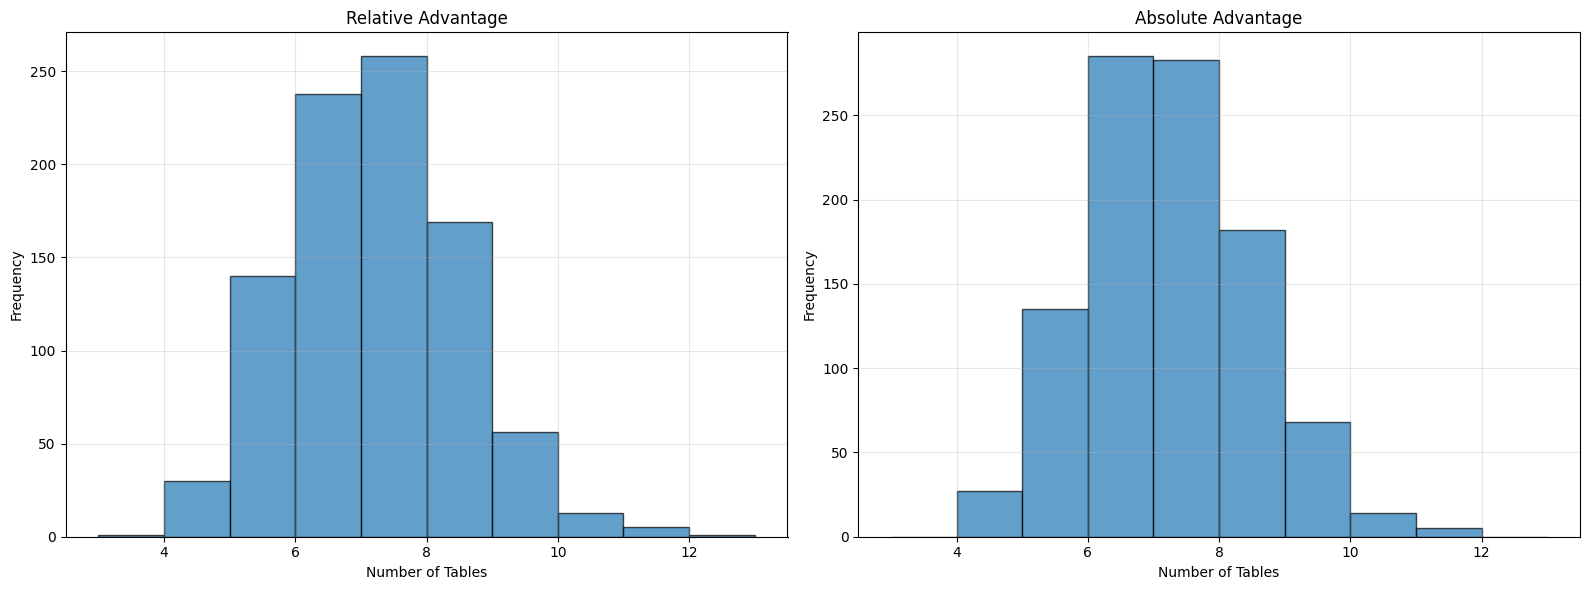

Relative Advantage:
  Mean: 6.71
  Min: 3, Max: 12
  Distribution: {7: 258, 8: 169, 10: 13, 9: 56, 11: 5, 6: 238, 5: 140, 4: 30, 12: 1, 3: 1}

Absolute Advantage:
  Mean: 6.74
  Min: 4, Max: 11
  Distribution: {7: 283, 8: 182, 10: 14, 9: 68, 6: 285, 11: 5, 5: 135, 4: 27}


In [3]:
# Analysis 1: Histogram of # of tables per query
table_counts_rel = get_table_counts(df_rel, g)
table_counts_abs = get_table_counts(df_abs, g)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Relative
all_counts = table_counts_rel + table_counts_abs
bins = range(min(all_counts), max(all_counts) + 2)
ax1.hist(table_counts_rel, bins=bins, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Tables')
ax1.set_ylabel('Frequency')
ax1.set_title('Relative Advantage')
ax1.grid(True, alpha=0.3)

# Absolute
ax2.hist(table_counts_abs, bins=bins, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Tables')
ax2.set_ylabel('Frequency')
ax2.set_title('Absolute Advantage')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Relative Advantage:")
print(f"  Mean: {sum(table_counts_rel) / len(table_counts_rel):.2f}")
print(f"  Min: {min(table_counts_rel)}, Max: {max(table_counts_rel)}")
print(f"  Distribution: {dict(Counter(table_counts_rel))}")

print("\nAbsolute Advantage:")
print(f"  Mean: {sum(table_counts_abs) / len(table_counts_abs):.2f}")
print(f"  Min: {min(table_counts_abs)}, Max: {max(table_counts_abs)}")
print(f"  Distribution: {dict(Counter(table_counts_abs))}")


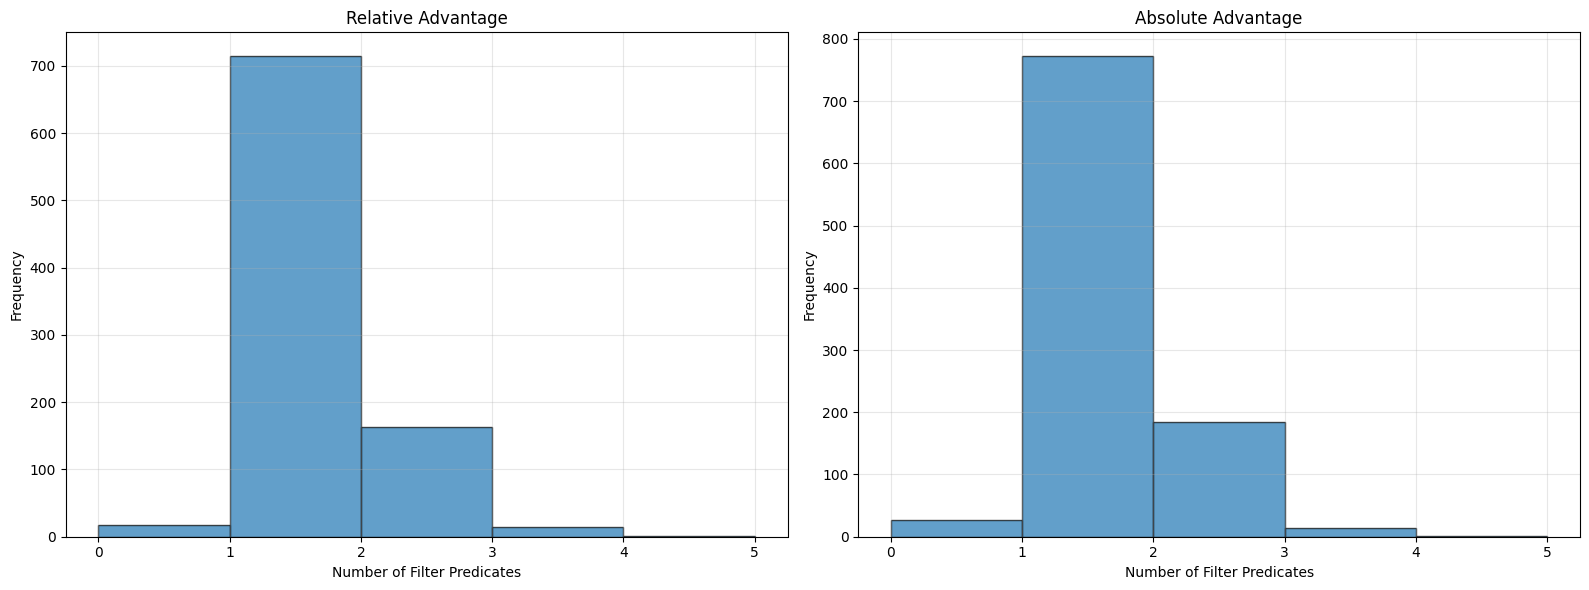

Relative Advantage:
  Mean: 1.20
  Min: 0, Max: 4
  Distribution: {1: 714, 2: 163, 0: 18, 3: 15, 4: 1}

Absolute Advantage:
  Mean: 1.19
  Min: 0, Max: 4
  Distribution: {1: 772, 2: 185, 3: 14, 0: 27, 4: 1}


In [4]:
# Analysis 2: Histogram of # of filter predicates per query
filter_counts_rel = get_filter_counts(df_rel, g)
filter_counts_abs = get_filter_counts(df_abs, g)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Relative
all_counts = filter_counts_rel + filter_counts_abs
bins = range(min(all_counts), max(all_counts) + 2)
ax1.hist(filter_counts_rel, bins=bins, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Filter Predicates')
ax1.set_ylabel('Frequency')
ax1.set_title('Relative Advantage')
ax1.grid(True, alpha=0.3)

# Absolute
ax2.hist(filter_counts_abs, bins=bins, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Filter Predicates')
ax2.set_ylabel('Frequency')
ax2.set_title('Absolute Advantage')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Relative Advantage:")
print(f"  Mean: {sum(filter_counts_rel) / len(filter_counts_rel):.2f}")
print(f"  Min: {min(filter_counts_rel)}, Max: {max(filter_counts_rel)}")
print(f"  Distribution: {dict(Counter(filter_counts_rel))}")

print("\nAbsolute Advantage:")
print(f"  Mean: {sum(filter_counts_abs) / len(filter_counts_abs):.2f}")
print(f"  Min: {min(filter_counts_abs)}, Max: {max(filter_counts_abs)}")
print(f"  Distribution: {dict(Counter(filter_counts_abs))}")


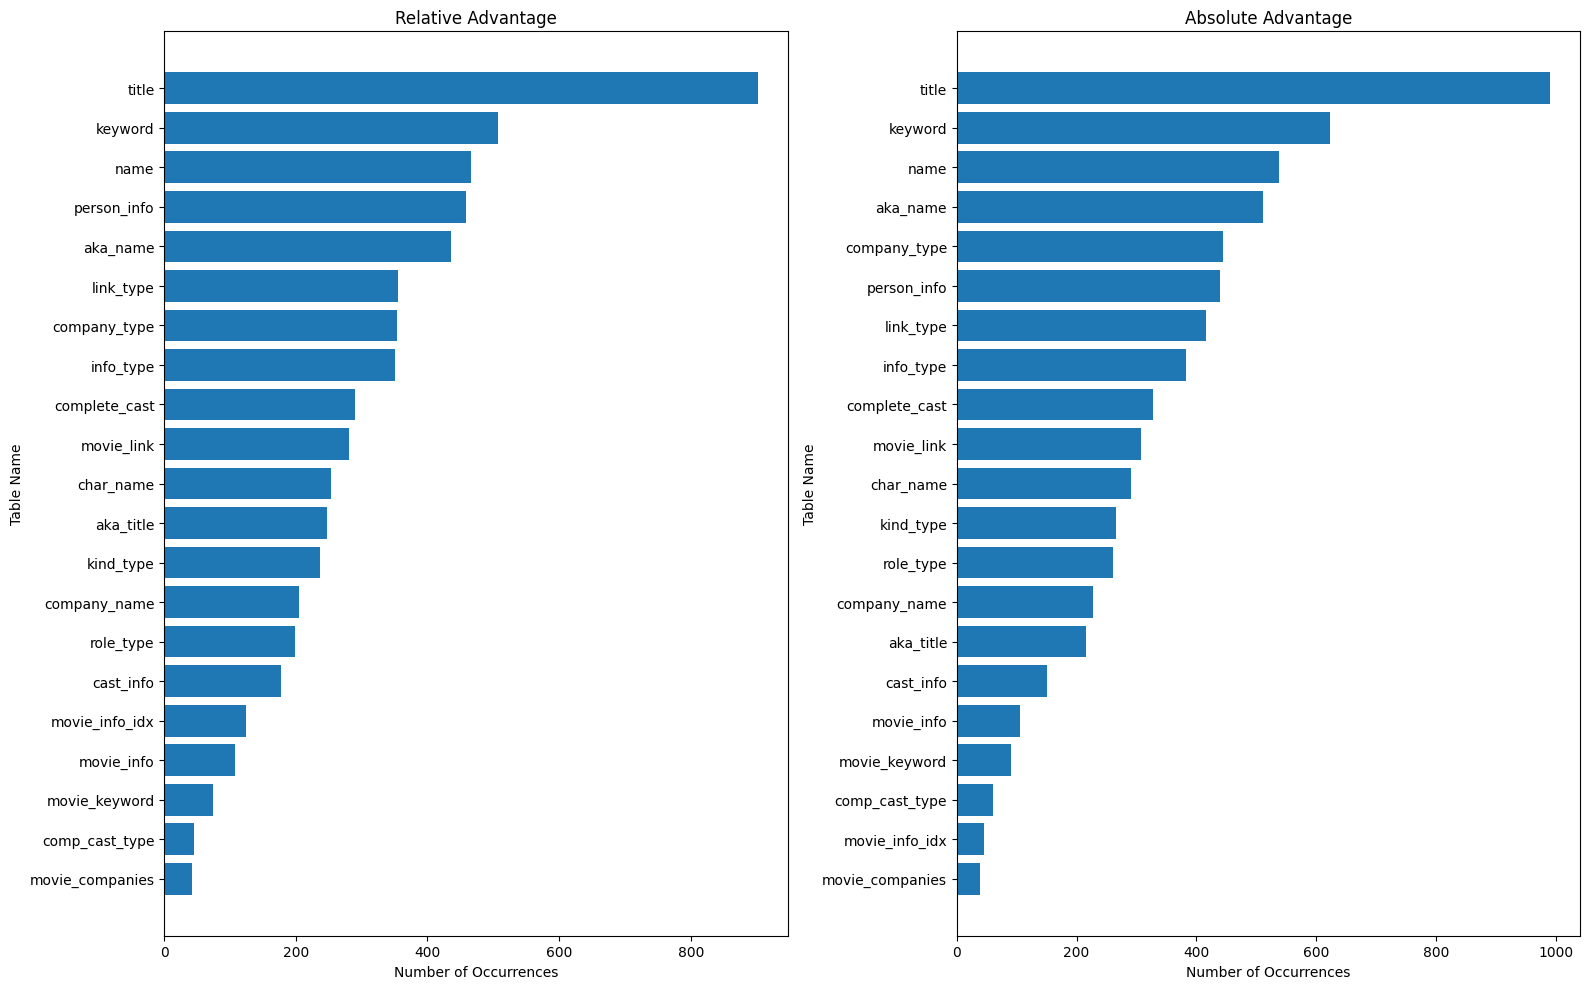

Relative Advantage:
  Total unique tables: 21
  Top 10 most frequent tables:
    title: 902
    keyword: 507
    name: 466
    person_info: 458
    aka_name: 436
    link_type: 355
    company_type: 353
    info_type: 350
    complete_cast: 290
    movie_link: 281

Absolute Advantage:
  Total unique tables: 21
  Top 10 most frequent tables:
    title: 991
    keyword: 623
    name: 538
    aka_name: 511
    company_type: 445
    person_info: 439
    link_type: 416
    info_type: 383
    complete_cast: 328
    movie_link: 308


In [5]:
# Analysis 3: # of occurrences of a given table
table_occurrences_rel = get_table_occurrences(df_rel, g)
table_occurrences_abs = get_table_occurrences(df_abs, g)

sorted_tables_rel = sorted(table_occurrences_rel.items(), key=lambda x: x[1], reverse=True)
sorted_tables_abs = sorted(table_occurrences_abs.items(), key=lambda x: x[1], reverse=True)

# Get all unique tables for consistent ordering
all_tables = set(table_occurrences_rel.keys()) | set(table_occurrences_abs.keys())
all_tables_sorted = sorted(all_tables, key=lambda t: max(
    table_occurrences_rel.get(t, 0), table_occurrences_abs.get(t, 0)
), reverse=True)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Relative
tables_rel, counts_rel = zip(*sorted_tables_rel)
ax1.barh(range(len(tables_rel)), counts_rel)
ax1.set_yticks(range(len(tables_rel)))
ax1.set_yticklabels(tables_rel)
ax1.set_xlabel('Number of Occurrences')
ax1.set_ylabel('Table Name')
ax1.set_title('Relative Advantage')
ax1.invert_yaxis()

# Absolute
tables_abs, counts_abs = zip(*sorted_tables_abs)
ax2.barh(range(len(tables_abs)), counts_abs)
ax2.set_yticks(range(len(tables_abs)))
ax2.set_yticklabels(tables_abs)
ax2.set_xlabel('Number of Occurrences')
ax2.set_ylabel('Table Name')
ax2.set_title('Absolute Advantage')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("Relative Advantage:")
print(f"  Total unique tables: {len(table_occurrences_rel)}")
print(f"  Top 10 most frequent tables:")
for table, count in sorted_tables_rel[:10]:
    print(f"    {table}: {count}")

print("\nAbsolute Advantage:")
print(f"  Total unique tables: {len(table_occurrences_abs)}")
print(f"  Top 10 most frequent tables:")
for table, count in sorted_tables_abs[:10]:
    print(f"    {table}: {count}")


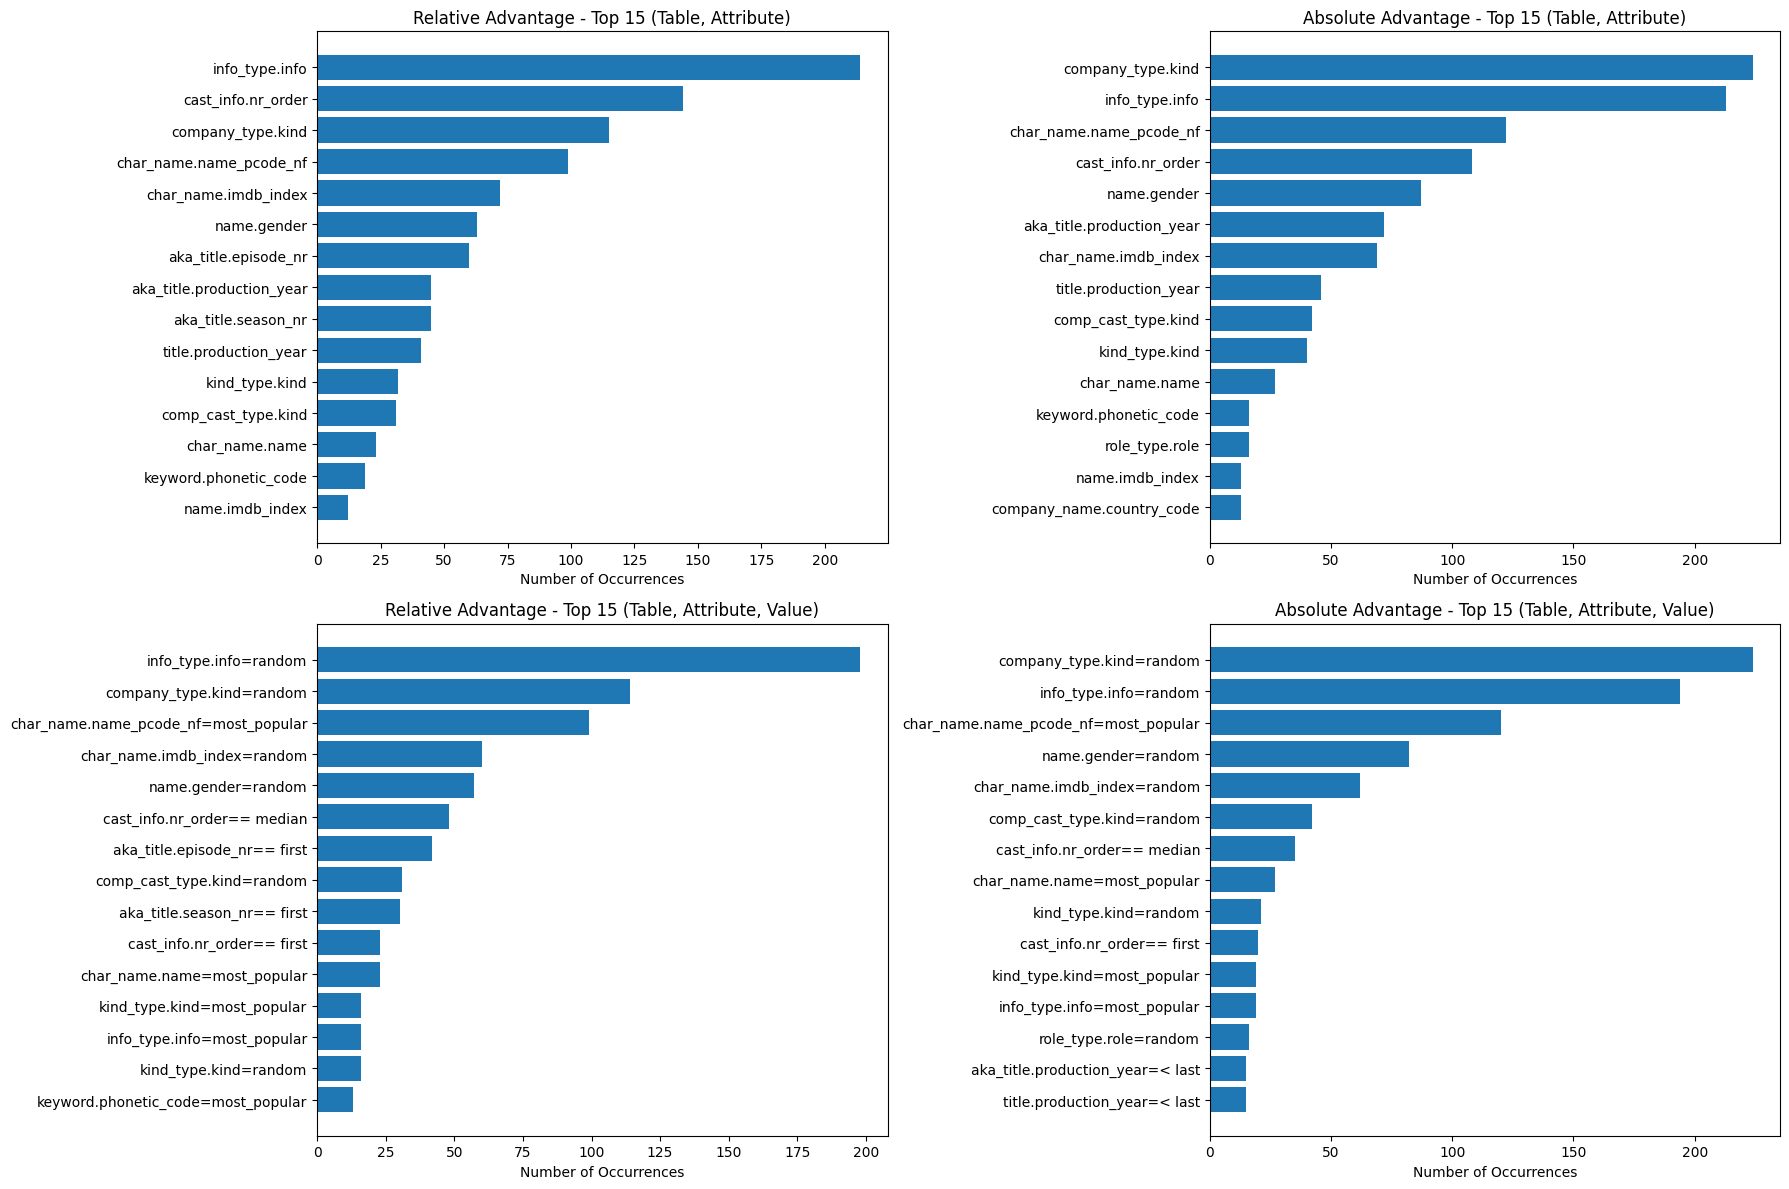

Relative Advantage:
  Total unique (table, attribute) patterns: 33
  Total unique (table, attribute, value) patterns: 161
  Top 10 (table, attribute) patterns:
    (info_type, info): 214
    (cast_info, nr_order): 144
    (company_type, kind): 115
    (char_name, name_pcode_nf): 99
    (char_name, imdb_index): 72
    (name, gender): 63
    (aka_title, episode_nr): 60
    (aka_title, production_year): 45
    (aka_title, season_nr): 45
    (title, production_year): 41
  Top 10 (table, attribute, value) patterns:
    (info_type, info, random): 198
    (company_type, kind, random): 114
    (char_name, name_pcode_nf, most_popular): 99
    (char_name, imdb_index, random): 60
    (name, gender, random): 57
    (cast_info, nr_order, = median): 48
    (aka_title, episode_nr, = first): 42
    (comp_cast_type, kind, random): 31
    (aka_title, season_nr, = first): 30
    (cast_info, nr_order, = first): 23

Absolute Advantage:
  Total unique (table, attribute) patterns: 33
  Total unique (table, a

In [6]:
# Analysis 4: # of occurrences of (table (predicate)) patterns
# 4a: By attribute only (e.g., (name (gender ...)))
# 4b: By attribute and predicate values (e.g., (info_type (info random)))

predicate_by_attribute_rel, predicate_by_attribute_value_rel = get_predicate_patterns(df_rel, g)
predicate_by_attribute_abs, predicate_by_attribute_value_abs = get_predicate_patterns(df_abs, g)

sorted_by_attr_rel = sorted(predicate_by_attribute_rel.items(), key=lambda x: x[1], reverse=True)
sorted_by_attr_val_rel = sorted(predicate_by_attribute_value_rel.items(), key=lambda x: x[1], reverse=True)
sorted_by_attr_abs = sorted(predicate_by_attribute_abs.items(), key=lambda x: x[1], reverse=True)
sorted_by_attr_val_abs = sorted(predicate_by_attribute_value_abs.items(), key=lambda x: x[1], reverse=True)

# Plot 4a: By attribute - side by side
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Relative - by attribute
top_attr_rel = sorted_by_attr_rel[:15]
attr_labels_rel = [f"{table}.{attr}" for (table, attr), _ in top_attr_rel]
attr_counts_rel = [count for _, count in top_attr_rel]
axes[0, 0].barh(range(len(attr_labels_rel)), attr_counts_rel)
axes[0, 0].set_yticks(range(len(attr_labels_rel)))
axes[0, 0].set_yticklabels(attr_labels_rel)
axes[0, 0].set_xlabel('Number of Occurrences')
axes[0, 0].set_title('Relative Advantage - Top 15 (Table, Attribute)')
axes[0, 0].invert_yaxis()

# Absolute - by attribute
top_attr_abs = sorted_by_attr_abs[:15]
attr_labels_abs = [f"{table}.{attr}" for (table, attr), _ in top_attr_abs]
attr_counts_abs = [count for _, count in top_attr_abs]
axes[0, 1].barh(range(len(attr_labels_abs)), attr_counts_abs)
axes[0, 1].set_yticks(range(len(attr_labels_abs)))
axes[0, 1].set_yticklabels(attr_labels_abs)
axes[0, 1].set_xlabel('Number of Occurrences')
axes[0, 1].set_title('Absolute Advantage - Top 15 (Table, Attribute)')
axes[0, 1].invert_yaxis()

# Relative - by attribute+value
top_attr_val_rel = sorted_by_attr_val_rel[:15]
attr_val_labels_rel = [f"{table}.{attr}={val}" for (table, attr, val), _ in top_attr_val_rel]
attr_val_counts_rel = [count for _, count in top_attr_val_rel]
axes[1, 0].barh(range(len(attr_val_labels_rel)), attr_val_counts_rel)
axes[1, 0].set_yticks(range(len(attr_val_labels_rel)))
axes[1, 0].set_yticklabels(attr_val_labels_rel)
axes[1, 0].set_xlabel('Number of Occurrences')
axes[1, 0].set_title('Relative Advantage - Top 15 (Table, Attribute, Value)')
axes[1, 0].invert_yaxis()

# Absolute - by attribute+value
top_attr_val_abs = sorted_by_attr_val_abs[:15]
attr_val_labels_abs = [f"{table}.{attr}={val}" for (table, attr, val), _ in top_attr_val_abs]
attr_val_counts_abs = [count for _, count in top_attr_val_abs]
axes[1, 1].barh(range(len(attr_val_labels_abs)), attr_val_counts_abs)
axes[1, 1].set_yticks(range(len(attr_val_labels_abs)))
axes[1, 1].set_yticklabels(attr_val_labels_abs)
axes[1, 1].set_xlabel('Number of Occurrences')
axes[1, 1].set_title('Absolute Advantage - Top 15 (Table, Attribute, Value)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Relative Advantage:")
print(f"  Total unique (table, attribute) patterns: {len(predicate_by_attribute_rel)}")
print(f"  Total unique (table, attribute, value) patterns: {len(predicate_by_attribute_value_rel)}")
print(f"  Top 10 (table, attribute) patterns:")
for (table, attr), count in sorted_by_attr_rel[:10]:
    print(f"    ({table}, {attr}): {count}")
print(f"  Top 10 (table, attribute, value) patterns:")
for (table, attr, val), count in sorted_by_attr_val_rel[:10]:
    print(f"    ({table}, {attr}, {val}): {count}")

print("\nAbsolute Advantage:")
print(f"  Total unique (table, attribute) patterns: {len(predicate_by_attribute_abs)}")
print(f"  Total unique (table, attribute, value) patterns: {len(predicate_by_attribute_value_abs)}")
print(f"  Top 10 (table, attribute) patterns:")
for (table, attr), count in sorted_by_attr_abs[:10]:
    print(f"    ({table}, {attr}): {count}")
print(f"  Top 10 (table, attribute, value) patterns:")
for (table, attr, val), count in sorted_by_attr_val_abs[:10]:
    print(f"    ({table}, {attr}, {val}): {count}")


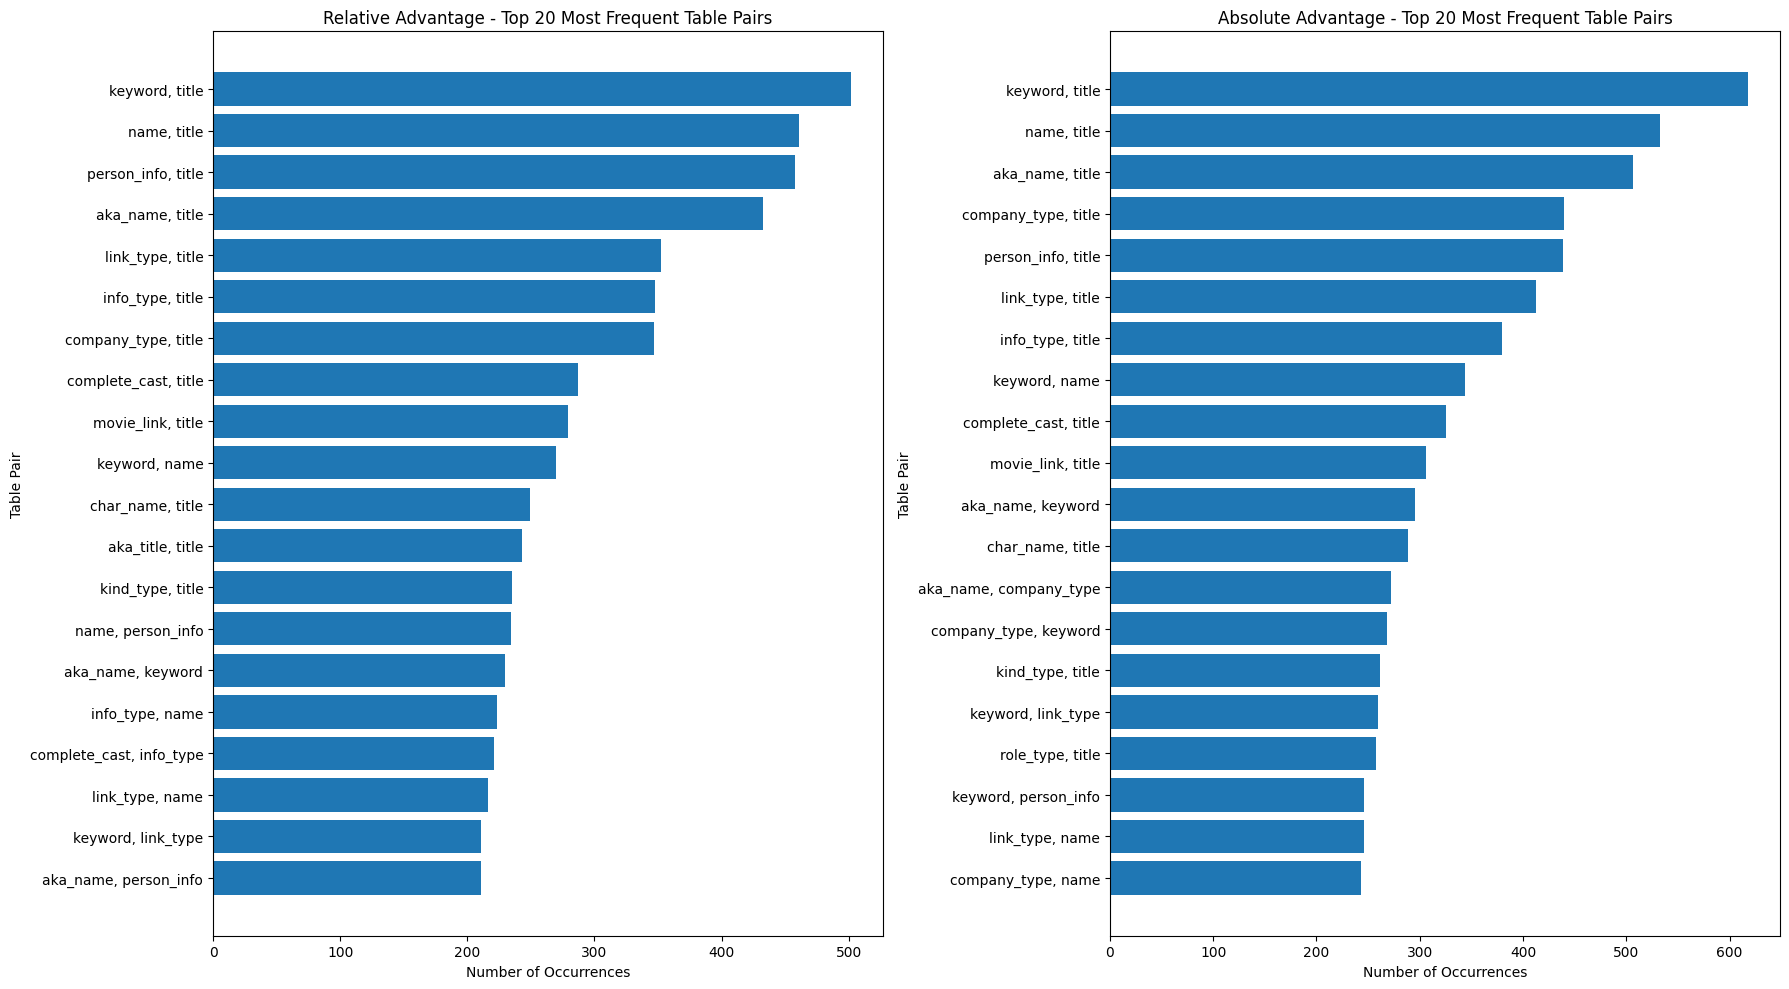

Relative Advantage:
  Total unique table pairs: 210
  Top 15 most frequent table pairs:
    (keyword, title): 502
    (name, title): 461
    (person_info, title): 458
    (aka_name, title): 433
    (link_type, title): 352
    (info_type, title): 348
    (company_type, title): 347
    (complete_cast, title): 287
    (movie_link, title): 279
    (keyword, name): 270
    (char_name, title): 249
    (aka_title, title): 243
    (kind_type, title): 235
    (name, person_info): 234
    (aka_name, keyword): 230

Absolute Advantage:
  Total unique table pairs: 210
  Top 15 most frequent table pairs:
    (keyword, title): 618
    (name, title): 533
    (aka_name, title): 507
    (company_type, title): 440
    (person_info, title): 439
    (link_type, title): 413
    (info_type, title): 380
    (keyword, name): 344
    (complete_cast, title): 325
    (movie_link, title): 306
    (aka_name, keyword): 295
    (char_name, title): 289
    (aka_name, company_type): 272
    (company_type, keyword): 268

In [7]:
# Analysis 5: # of occurrences of pairs of tables
table_pairs_rel = get_table_pairs(df_rel, g)
table_pairs_abs = get_table_pairs(df_abs, g)

sorted_pairs_rel = sorted(table_pairs_rel.items(), key=lambda x: x[1], reverse=True)
sorted_pairs_abs = sorted(table_pairs_abs.items(), key=lambda x: x[1], reverse=True)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# Relative
top_pairs_rel = sorted_pairs_rel[:20]
pair_labels_rel = [f"{pair[0]}, {pair[1]}" for pair, _ in top_pairs_rel]
pair_counts_rel = [count for _, count in top_pairs_rel]
ax1.barh(range(len(pair_labels_rel)), pair_counts_rel)
ax1.set_yticks(range(len(pair_labels_rel)))
ax1.set_yticklabels(pair_labels_rel)
ax1.set_xlabel('Number of Occurrences')
ax1.set_ylabel('Table Pair')
ax1.set_title('Relative Advantage - Top 20 Most Frequent Table Pairs')
ax1.invert_yaxis()

# Absolute
top_pairs_abs = sorted_pairs_abs[:20]
pair_labels_abs = [f"{pair[0]}, {pair[1]}" for pair, _ in top_pairs_abs]
pair_counts_abs = [count for _, count in top_pairs_abs]
ax2.barh(range(len(pair_labels_abs)), pair_counts_abs)
ax2.set_yticks(range(len(pair_labels_abs)))
ax2.set_yticklabels(pair_labels_abs)
ax2.set_xlabel('Number of Occurrences')
ax2.set_ylabel('Table Pair')
ax2.set_title('Absolute Advantage - Top 20 Most Frequent Table Pairs')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("Relative Advantage:")
print(f"  Total unique table pairs: {len(table_pairs_rel)}")
print(f"  Top 15 most frequent table pairs:")
for (table1, table2), count in sorted_pairs_rel[:15]:
    print(f"    ({table1}, {table2}): {count}")

print("\nAbsolute Advantage:")
print(f"  Total unique table pairs: {len(table_pairs_abs)}")
print(f"  Top 15 most frequent table pairs:")
for (table1, table2), count in sorted_pairs_abs[:15]:
    print(f"    ({table1}, {table2}): {count}")


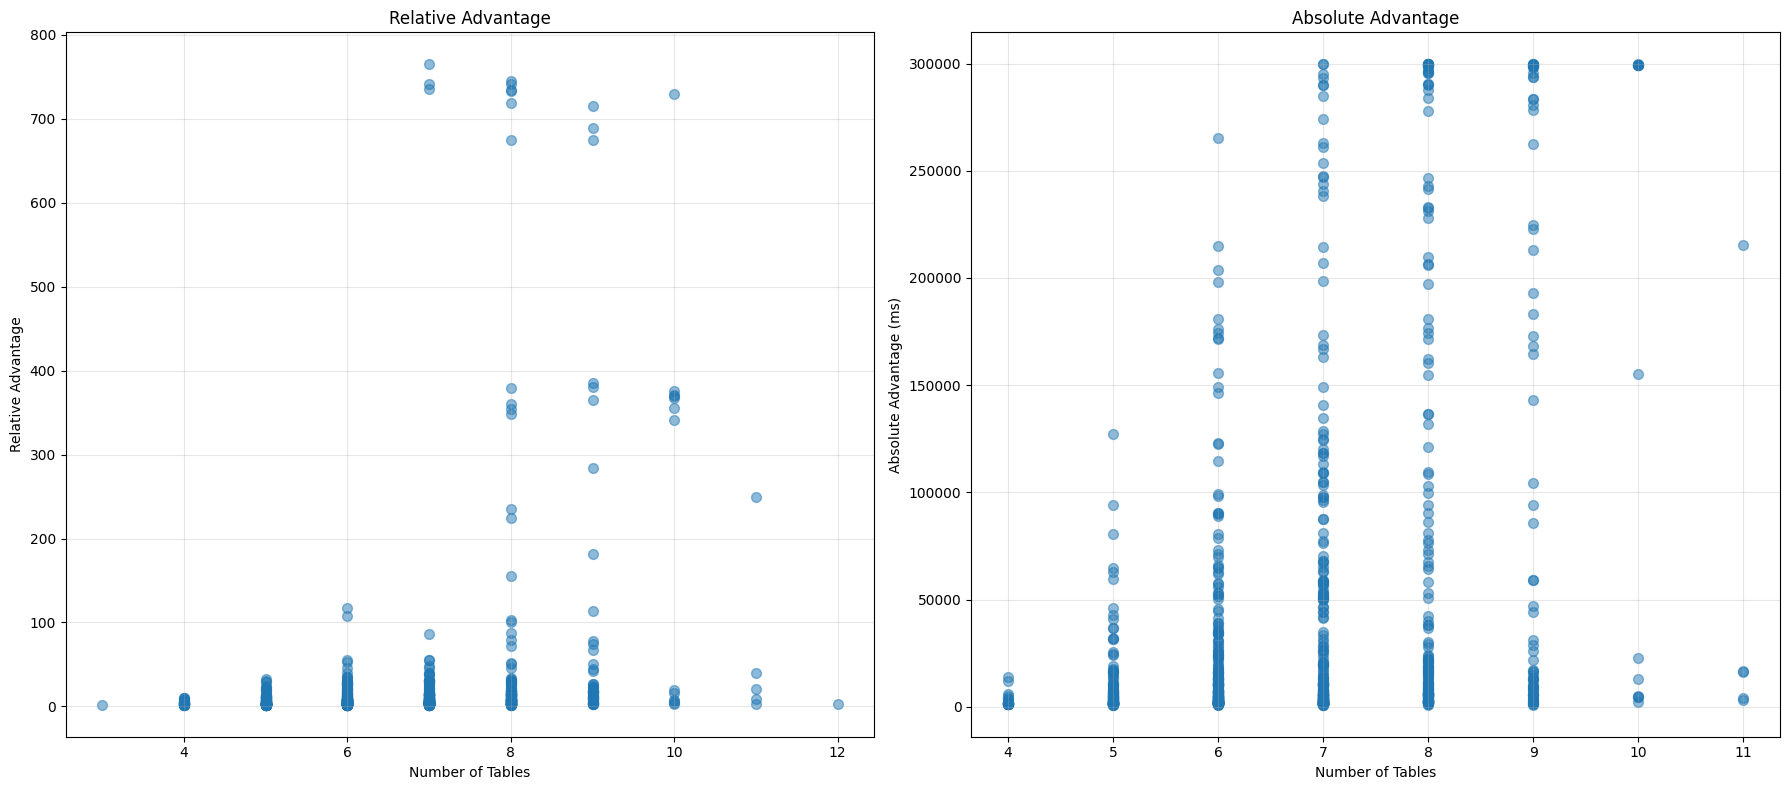

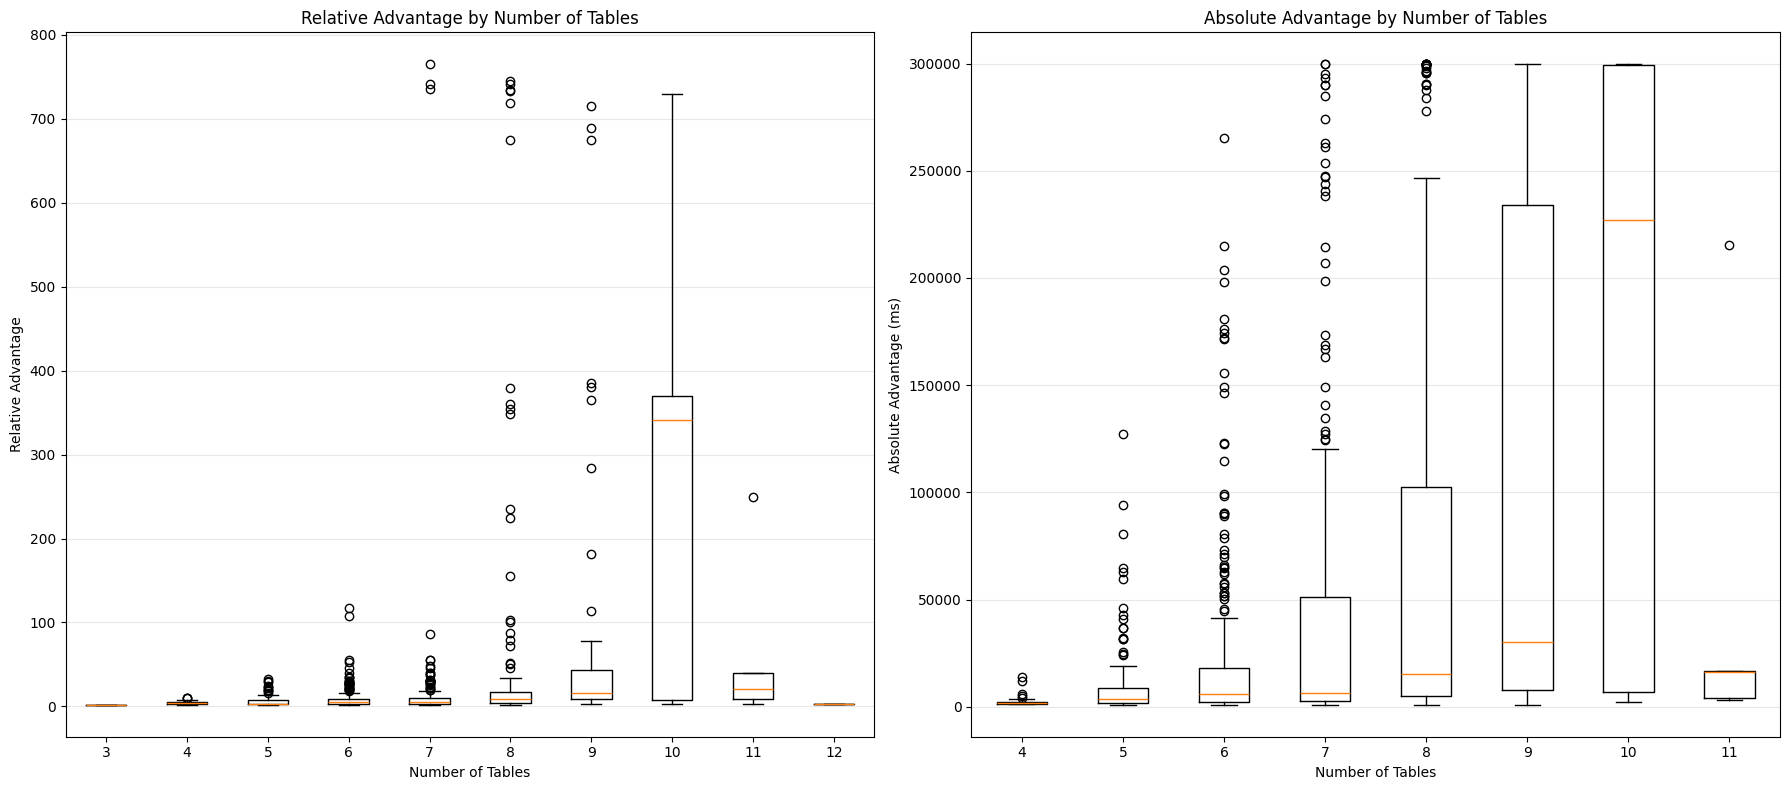

Relative Advantage - Summary statistics by number of tables:
  3 tables: mean=2.21, median=2.21, std=0.00, count=1
  4 tables: mean=4.29, median=3.48, std=2.40, count=30
  5 tables: mean=6.01, median=3.43, std=5.87, count=140
  6 tables: mean=9.03, median=4.94, std=13.02, count=238
  7 tables: mean=17.46, median=5.10, std=79.87, count=258
  8 tables: mean=50.15, median=8.37, std=142.87, count=169
  9 tables: mean=82.85, median=16.26, std=171.16, count=56
  10 tables: mean=228.17, median=341.06, std=223.66, count=13
  11 tables: mean=64.14, median=20.18, std=93.31, count=5
  12 tables: mean=2.42, median=2.42, std=0.00, count=1

Absolute Advantage - Summary statistics by number of tables:
  4 tables: mean=2910.65, median=1710.75, std=3116.08, count=27
  5 tables: mean=10441.64, median=3661.92, std=18541.87, count=135
  6 tables: mean=22373.34, median=5829.90, std=41217.18, count=285
  7 tables: mean=41283.12, median=6436.44, std=70093.15, count=283
  8 tables: mean=71538.68, median=15262

In [8]:
# Final Analysis: Distribution of # of tables vs. advantage
table_counts_with_advantage_rel = []
table_counts_with_advantage_abs = []

for idx, query_str in enumerate(df_rel['query']):
    try:
        t = g.parse(query_str)
        num_tables = len(t.children)
        relative_advantage = df_rel.iloc[idx]['relative_advantage']
        table_counts_with_advantage_rel.append((num_tables, relative_advantage))
    except Exception as e:
        continue

for idx, query_str in enumerate(df_abs['query']):
    try:
        t = g.parse(query_str)
        num_tables = len(t.children)
        absolute_advantage = df_abs.iloc[idx]['absolute_advantage_ms']
        table_counts_with_advantage_abs.append((num_tables, absolute_advantage))
    except Exception as e:
        continue

tables_list_rel, advantages_list_rel = zip(*table_counts_with_advantage_rel)
tables_list_abs, advantages_list_abs = zip(*table_counts_with_advantage_abs)

# Scatter plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.scatter(tables_list_rel, advantages_list_rel, alpha=0.5, s=50)
ax1.set_xlabel('Number of Tables')
ax1.set_ylabel('Relative Advantage')
ax1.set_title('Relative Advantage')
ax1.grid(True, alpha=0.3)

ax2.scatter(tables_list_abs, advantages_list_abs, alpha=0.5, s=50)
ax2.set_xlabel('Number of Tables')
ax2.set_ylabel('Absolute Advantage (ms)')
ax2.set_title('Absolute Advantage')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots side-by-side
advantages_by_table_count_rel = defaultdict(list)
for num_tables, advantage in table_counts_with_advantage_rel:
    advantages_by_table_count_rel[num_tables].append(advantage)

advantages_by_table_count_abs = defaultdict(list)
for num_tables, advantage in table_counts_with_advantage_abs:
    advantages_by_table_count_abs[num_tables].append(advantage)

table_counts_sorted_rel = sorted(advantages_by_table_count_rel.keys())
table_counts_sorted_abs = sorted(advantages_by_table_count_abs.keys())
box_data_rel = [advantages_by_table_count_rel[count] for count in table_counts_sorted_rel]
box_data_abs = [advantages_by_table_count_abs[count] for count in table_counts_sorted_abs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.boxplot(box_data_rel, tick_labels=table_counts_sorted_rel)
ax1.set_xlabel('Number of Tables')
ax1.set_ylabel('Relative Advantage')
ax1.set_title('Relative Advantage by Number of Tables')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot(box_data_abs, tick_labels=table_counts_sorted_abs)
ax2.set_xlabel('Number of Tables')
ax2.set_ylabel('Absolute Advantage (ms)')
ax2.set_title('Absolute Advantage by Number of Tables')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Relative Advantage - Summary statistics by number of tables:")
for count in sorted(advantages_by_table_count_rel.keys()):
    advantages = advantages_by_table_count_rel[count]
    print(f"  {count} tables: mean={np.mean(advantages):.2f}, median={np.median(advantages):.2f}, "
          f"std={np.std(advantages):.2f}, count={len(advantages)}")

print("\nAbsolute Advantage - Summary statistics by number of tables:")
for count in sorted(advantages_by_table_count_abs.keys()):
    advantages = advantages_by_table_count_abs[count]
    print(f"  {count} tables: mean={np.mean(advantages):.2f}, median={np.median(advantages):.2f}, "
          f"std={np.std(advantages):.2f}, count={len(advantages)}")


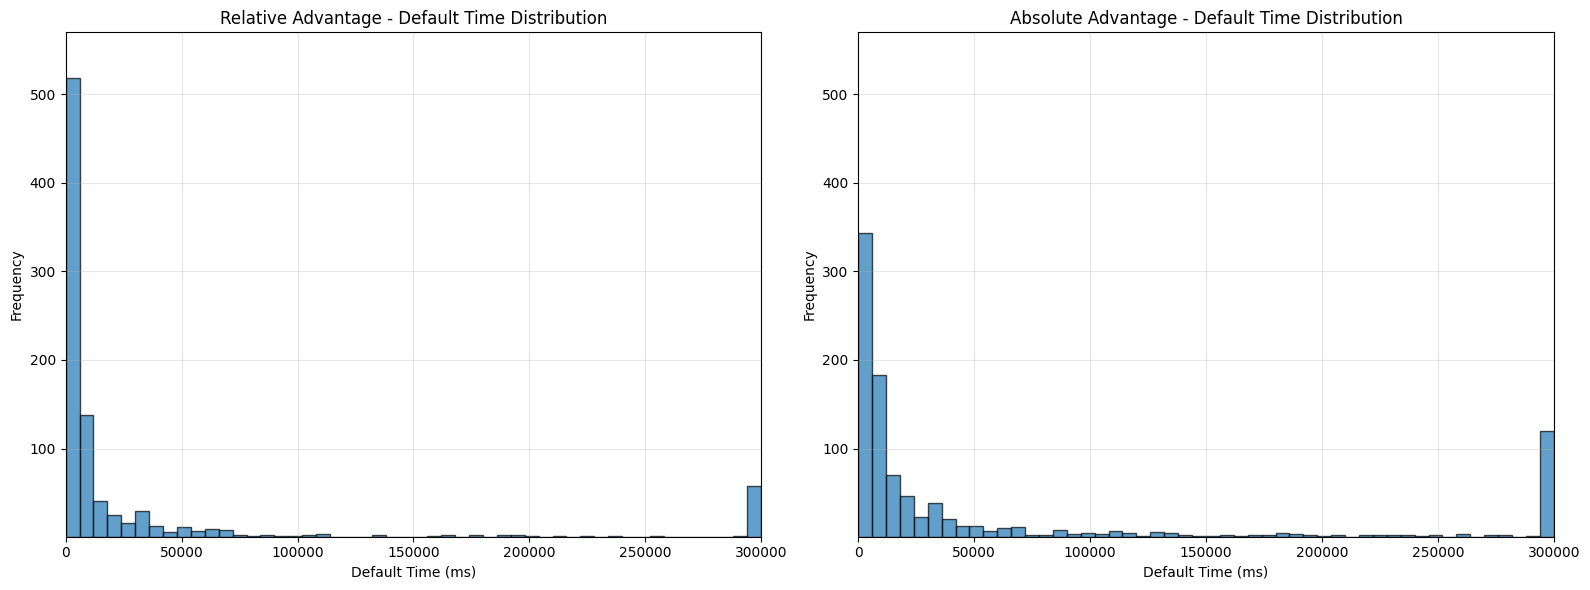

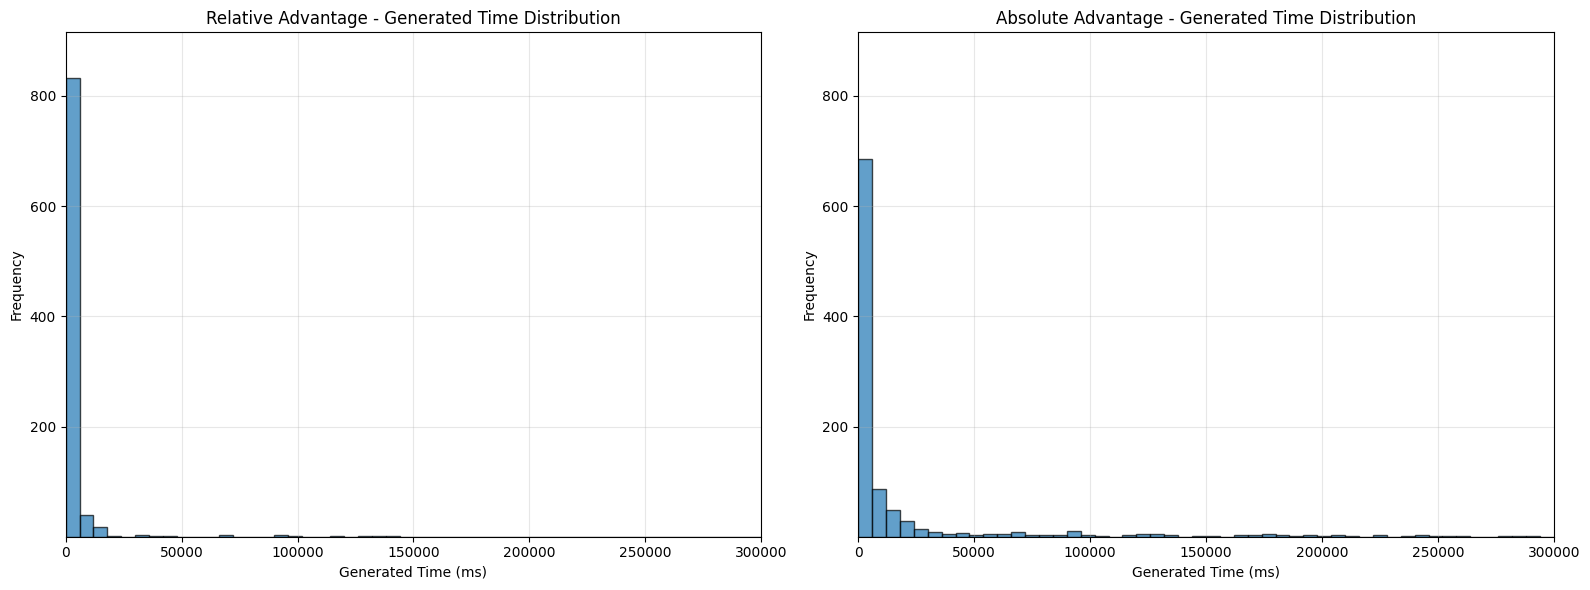

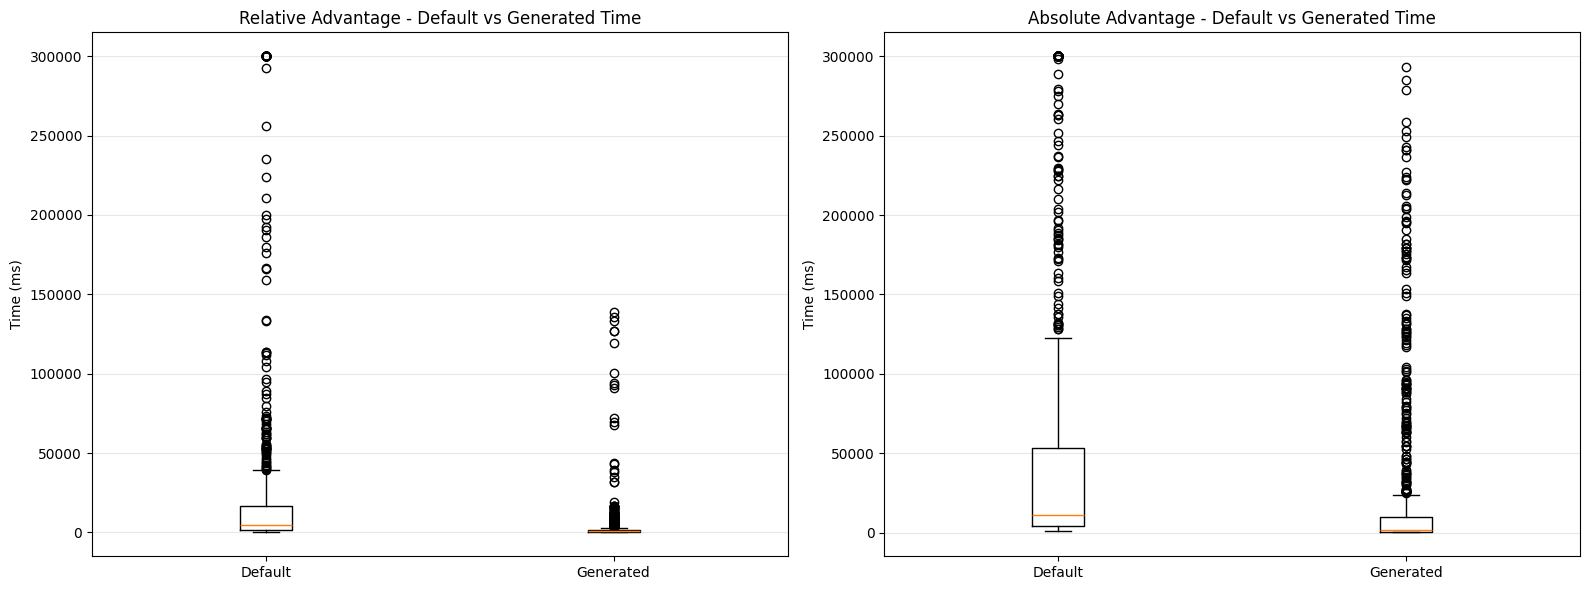

Relative Advantage:
  Default Time - Mean: 32673.58 ms, Median: 4422.95 ms, Std: 76201.14 ms
  Generated Time - Mean: 3375.24 ms, Median: 656.96 ms, Std: 13300.08 ms

Absolute Advantage:
  Default Time - Mean: 61983.75 ms, Median: 11097.17 ms, Std: 100387.60 ms
  Generated Time - Mean: 19325.61 ms, Median: 1878.10 ms, Std: 46329.37 ms


In [9]:
# Analysis: Distribution of default_time_ms and generated_time_ms
default_times_rel = df_rel['default_time_ms'].values
generated_times_rel = df_rel['generated_time_ms'].values
default_times_abs = df_abs['default_time_ms'].values
generated_times_abs = df_abs['generated_time_ms'].values

# Define consistent bins across all histograms (0 to 300000)
x_min, x_max = 0, 300000
num_bins = 50
bins = np.linspace(x_min, x_max, num_bins + 1)

# Histograms side-by-side for default_time_ms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compute histograms to get counts for consistent y-axis
counts_rel_default, _ = np.histogram(default_times_rel, bins=bins)
counts_abs_default, _ = np.histogram(default_times_abs, bins=bins)
y_max_default = max(np.max(counts_rel_default), np.max(counts_abs_default)) * 1.1  # Add 10% padding

axes[0].hist(default_times_rel, bins=bins, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Default Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Relative Advantage - Default Time Distribution')
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(0.5, y_max_default)  # Start at 0.5 for log scale
# axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].hist(default_times_abs, bins=bins, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Default Time (ms)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Absolute Advantage - Default Time Distribution')
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(0.5, y_max_default)  # Same y-axis range
# axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Histograms side-by-side for generated_time_ms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compute histograms to get counts for consistent y-axis
counts_rel_gen, _ = np.histogram(generated_times_rel, bins=bins)
counts_abs_gen, _ = np.histogram(generated_times_abs, bins=bins)
y_max_gen = max(np.max(counts_rel_gen), np.max(counts_abs_gen)) * 1.1  # Add 10% padding

axes[0].hist(generated_times_rel, bins=bins, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Generated Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Relative Advantage - Generated Time Distribution')
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(0.5, y_max_gen)  # Start at 0.5 for log scale
# axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].hist(generated_times_abs, bins=bins, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Generated Time (ms)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Absolute Advantage - Generated Time Distribution')
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(0.5, y_max_gen)  # Same y-axis range
# axes[0].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots comparing default vs generated for both datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relative Advantage
axes[0].boxplot([default_times_rel, generated_times_rel], tick_labels=['Default', 'Generated'])
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Relative Advantage - Default vs Generated Time')
# axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3, axis='y')

# Absolute Advantage
axes[1].boxplot([default_times_abs, generated_times_abs], tick_labels=['Default', 'Generated'])
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Absolute Advantage - Default vs Generated Time')
# axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Relative Advantage:")
print(f"  Default Time - Mean: {np.mean(default_times_rel):.2f} ms, Median: {np.median(default_times_rel):.2f} ms, Std: {np.std(default_times_rel):.2f} ms")
print(f"  Generated Time - Mean: {np.mean(generated_times_rel):.2f} ms, Median: {np.median(generated_times_rel):.2f} ms, Std: {np.std(generated_times_rel):.2f} ms")

print("\nAbsolute Advantage:")
print(f"  Default Time - Mean: {np.mean(default_times_abs):.2f} ms, Median: {np.median(default_times_abs):.2f} ms, Std: {np.std(default_times_abs):.2f} ms")
print(f"  Generated Time - Mean: {np.mean(generated_times_abs):.2f} ms, Median: {np.median(generated_times_abs):.2f} ms, Std: {np.std(generated_times_abs):.2f} ms")


In [10]:
# Analysis: Count equivalent queries between relative and absolute datasets
def extract_query_signature(query_str, parser):
    """Extract a signature (set of tables and predicates) from a query string."""
    try:
        t = parser.parse(query_str)
        tables = set()
        predicates = set()
        
        for selector in t.children:
            table_name = str(selector.children[0])
            tables.add(table_name)
            
            for filt in selector.children[1:]:
                filt = filt.children[0]
                if filt.data == "int_filter":
                    field = str(filt.children[0])
                    operator = str(filt.children[1].children[0])
                    value = str(filt.children[2].children[0])
                    predicates.add((table_name, field, operator, value))
                elif filt.data == "str_filter":
                    field = str(filt.children[0])
                    str_val = str(filt.children[1].children[0])
                    predicates.add((table_name, field, str_val))
        
        return (frozenset(tables), frozenset(predicates))
    except Exception as e:
        return None

# Extract signatures for all queries
print("Extracting query signatures...")
signatures_rel = {}
for idx, query_str in enumerate(df_rel['query']):
    sig = extract_query_signature(query_str, g)
    if sig is not None:
        signatures_rel[sig] = signatures_rel.get(sig, []) + [idx]

signatures_abs = {}
for idx, query_str in enumerate(df_abs['query']):
    sig = extract_query_signature(query_str, g)
    if sig is not None:
        signatures_abs[sig] = signatures_abs.get(sig, []) + [idx]

print(f"Relative dataset: {len(df_rel)} queries, {len(signatures_rel)} unique signatures")
print(f"Absolute dataset: {len(df_abs)} queries, {len(signatures_abs)} unique signatures")

# Find overlapping signatures
overlapping_signatures = set(signatures_rel.keys()) & set(signatures_abs.keys())
num_overlapping = len(overlapping_signatures)

# Count total queries that overlap
num_queries_rel_overlapping = sum(len(signatures_rel[sig]) for sig in overlapping_signatures)
num_queries_abs_overlapping = sum(len(signatures_abs[sig]) for sig in overlapping_signatures)

print(f"\nOverlap Analysis:")
print(f"  Unique equivalent query signatures: {num_overlapping}")
print(f"  Queries in relative dataset that have matches in absolute: {num_queries_rel_overlapping} ({100*num_queries_rel_overlapping/len(df_rel):.2f}%)")
print(f"  Queries in absolute dataset that have matches in relative: {num_queries_abs_overlapping} ({100*num_queries_abs_overlapping/len(df_abs):.2f}%)")

Extracting query signatures...
Relative dataset: 911 queries, 911 unique signatures
Absolute dataset: 999 queries, 999 unique signatures

Overlap Analysis:
  Unique equivalent query signatures: 683
  Queries in relative dataset that have matches in absolute: 683 (74.97%)
  Queries in absolute dataset that have matches in relative: 683 (68.37%)


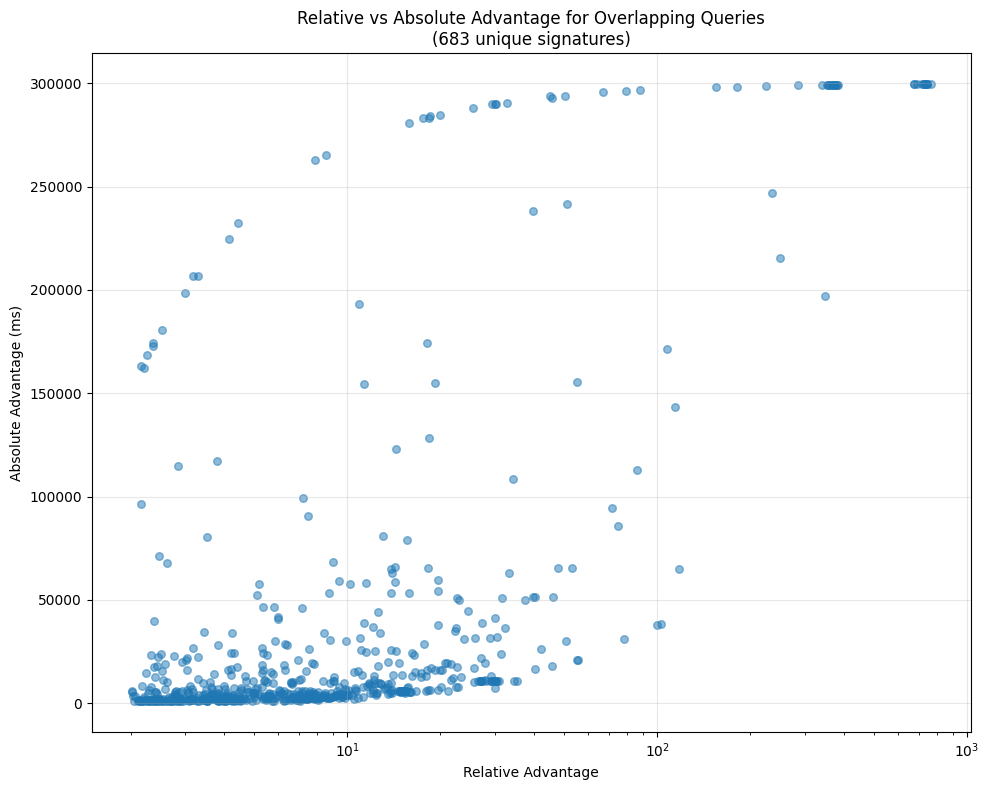

Total overlapping queries plotted: 683
Relative Advantage - Mean: 32.46, Median: 6.98, Std: 106.96
Absolute Advantage - Mean: 37753.83, Median: 5821.62, Std: 78474.04


In [11]:
# Scatter plot: Relative vs Absolute Advantage for overlapping queries
# Create dictionaries mapping signatures to advantage values (assuming one entry per signature)
rel_adv_by_sig = {}
for sig in signatures_rel:
    # Take the first occurrence if multiple exist
    idx = signatures_rel[sig][0]
    rel_adv_by_sig[sig] = df_rel.iloc[idx]['relative_advantage']

abs_adv_by_sig = {}
for sig in signatures_abs:
    # Take the first occurrence if multiple exist
    idx = signatures_abs[sig][0]
    abs_adv_by_sig[sig] = df_abs.iloc[idx]['absolute_advantage_ms']

# Extract advantages for overlapping signatures
rel_advantages = []
abs_advantages = []

for sig in overlapping_signatures:
    rel_advantages.append(rel_adv_by_sig[sig])
    abs_advantages.append(abs_adv_by_sig[sig])

plt.figure(figsize=(10, 8))
plt.scatter(rel_advantages, abs_advantages, alpha=0.5, s=30)
plt.xlabel('Relative Advantage')
plt.ylabel('Absolute Advantage (ms)')
plt.title(f'Relative vs Absolute Advantage for Overlapping Queries\n({len(overlapping_signatures)} unique signatures)')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total overlapping queries plotted: {len(rel_advantages)}")
print(f"Relative Advantage - Mean: {np.mean(rel_advantages):.2f}, Median: {np.median(rel_advantages):.2f}, Std: {np.std(rel_advantages):.2f}")
print(f"Absolute Advantage - Mean: {np.mean(abs_advantages):.2f}, Median: {np.median(abs_advantages):.2f}, Std: {np.std(abs_advantages):.2f}")


Overlapping signatures (unfiltered): 683

Overlapping queries plotted: 683
Relative-only queries (not in absolute): 228
Absolute-only queries (not in relative filtered): 316

Overlapping - Relative Advantage - Mean: 32.46, Median: 6.98, Std: 106.96
Overlapping - Absolute Advantage - Mean: 37753.83, Median: 5821.62, Std: 78474.04

Relative-only - Relative Advantage - Mean: 16.68, Median: 2.56, Std: 93.04
Relative-only - Absolute Advantage - Mean: 10543.18, Median: 866.40, Std: 44398.04

Absolute-only - Relative Advantage - Mean: 3.62, Median: 1.66, Std: 11.56
Absolute-only - Absolute Advantage - Mean: 53258.29, Median: 11615.68, Std: 75471.31


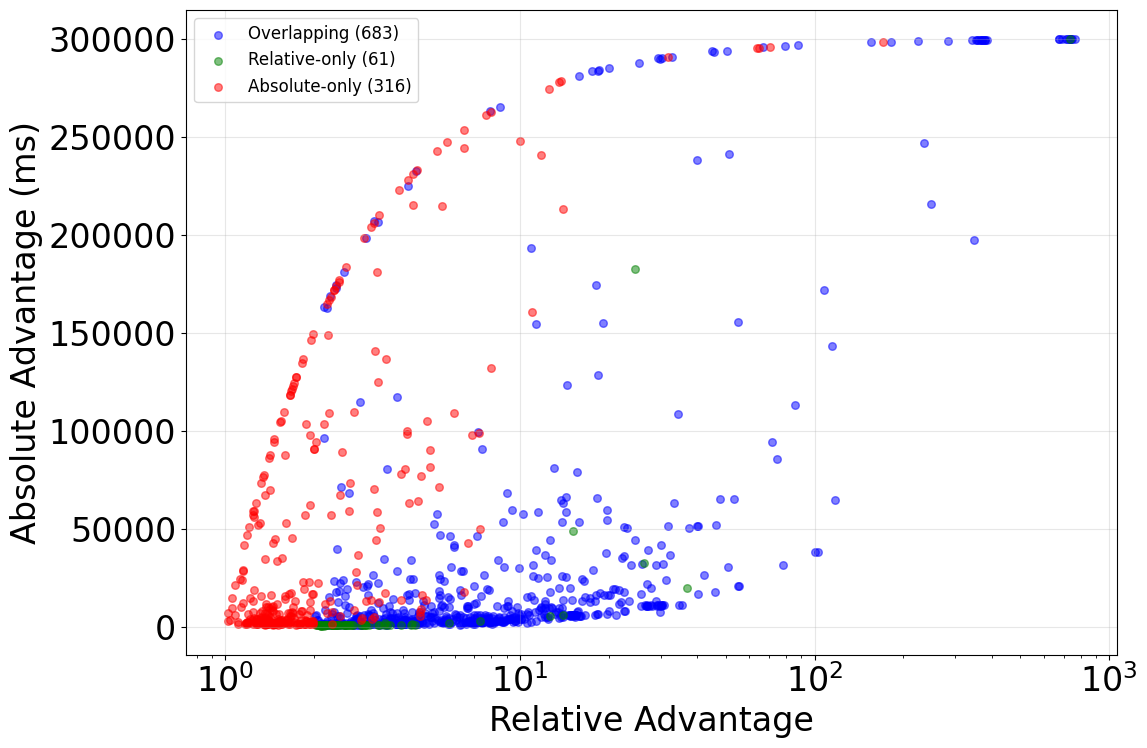

In [ ]:
# Scatter plot: Relative vs Absolute Advantage for overlapping queries
# Calculate overlap using unfiltered relative dataset
overlapping_signatures = set(signatures_rel.keys()) & set(signatures_abs.keys())
print(f"Overlapping signatures (unfiltered): {len(overlapping_signatures)}")

# Create dictionaries mapping signatures to advantage values and generated_time_ms
# Both datasets have both relative_advantage and absolute_advantage_ms columns
rel_rel_adv_by_sig = {}
rel_abs_adv_by_sig = {}
rel_gen_time_by_sig = {}
for sig in signatures_rel:
    idx = signatures_rel[sig][0]
    rel_rel_adv_by_sig[sig] = df_rel.iloc[idx]['relative_advantage']
    rel_abs_adv_by_sig[sig] = df_rel.iloc[idx]['absolute_advantage_ms']
    rel_gen_time_by_sig[sig] = df_rel.iloc[idx]['default_time_ms']

abs_rel_adv_by_sig = {}
abs_abs_adv_by_sig = {}
abs_gen_time_by_sig = {}
for sig in signatures_abs:
    idx = signatures_abs[sig][0]
    abs_rel_adv_by_sig[sig] = df_abs.iloc[idx]['relative_advantage']
    abs_abs_adv_by_sig[sig] = df_abs.iloc[idx]['absolute_advantage_ms']
    abs_gen_time_by_sig[sig] = df_abs.iloc[idx]['default_time_ms']

# Extract advantages for overlapping signatures, filtering by generated_time_ms > 1000
overlap_rel_adv = []
overlap_abs_adv = []

for sig in overlapping_signatures:
    # Check if either dataset has generated_time_ms > 1000
    if rel_gen_time_by_sig[sig] > 1000 or abs_gen_time_by_sig[sig] > 1000:
        # Use relative_advantage from relative dataset and absolute_advantage_ms from absolute dataset
        overlap_rel_adv.append(rel_rel_adv_by_sig[sig])
        overlap_abs_adv.append(abs_abs_adv_by_sig[sig])

# Find queries only in relative dataset (not in absolute)
rel_only_signatures = set(signatures_rel.keys()) - set(signatures_abs.keys())
rel_only_rel_adv = []
rel_only_abs_adv = []

for sig in rel_only_signatures:
    # Only include if generated_time_ms > 1000
    if rel_gen_time_by_sig[sig] > 1000:
        rel_only_rel_adv.append(rel_rel_adv_by_sig[sig])
        rel_only_abs_adv.append(rel_abs_adv_by_sig[sig])

# Find queries only in absolute dataset (not in relative)
abs_only_signatures = set(signatures_abs.keys()) - set(signatures_rel.keys())
abs_only_rel_adv = []
abs_only_abs_adv = []

for sig in abs_only_signatures:
    # Only include if generated_time_ms > 1000
    if abs_gen_time_by_sig[sig] > 1000:
        abs_only_rel_adv.append(abs_rel_adv_by_sig[sig])
        abs_only_abs_adv.append(abs_abs_adv_by_sig[sig])

# Create the plot with all three groups
plt.figure(figsize=(12, 8))

# Overlapping queries - use relative from rel dataset, absolute from abs dataset
plt.scatter(overlap_rel_adv, overlap_abs_adv, alpha=0.5, s=30, 
           label=f'Overlapping ({len(overlap_rel_adv)})', color='blue')

# Relative-only queries - use values from relative dataset
if len(rel_only_rel_adv) > 0:
    plt.scatter(rel_only_rel_adv, rel_only_abs_adv, alpha=0.5, s=30,
               label=f'Relative-only ({len(rel_only_rel_adv)})', color='green')

# Absolute-only queries - use values from absolute dataset
if len(abs_only_rel_adv) > 0:
    plt.scatter(abs_only_rel_adv, abs_only_abs_adv, alpha=0.5, s=30,
               label=f'Absolute-only ({len(abs_only_rel_adv)})', color='red')

font_size = 24
plt.rcParams["font.size"] = font_size
plt.xlabel('Relative Advantage', fontsize=font_size)
plt.ylabel('Absolute Advantage (ms)', fontsize=font_size)
# plt.title(f'Relative vs Absolute Advantage\n(Filtered: generated_time_ms > 1s)')
plt.xscale('log')
# Decrease legend font size
plt.legend(fontsize=font_size * 0.75)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.show()
plt.savefig('query_diversity.png', dpi=600)

print(f"\nOverlapping queries plotted: {len(overlap_rel_adv)}")
print(f"Relative-only queries (not in absolute): {len(rel_only_signatures)}")
print(f"Absolute-only queries (not in relative filtered): {len(abs_only_signatures)}")
print(f"\nOverlapping - Relative Advantage - Mean: {np.mean(overlap_rel_adv):.2f}, Median: {np.median(overlap_rel_adv):.2f}, Std: {np.std(overlap_rel_adv):.2f}")
print(f"Overlapping - Absolute Advantage - Mean: {np.mean(overlap_abs_adv):.2f}, Median: {np.median(overlap_abs_adv):.2f}, Std: {np.std(overlap_abs_adv):.2f}")
if len(rel_only_rel_adv) > 0:
    print(f"\nRelative-only - Relative Advantage - Mean: {np.mean(rel_only_rel_adv):.2f}, Median: {np.median(rel_only_rel_adv):.2f}, Std: {np.std(rel_only_rel_adv):.2f}")
    print(f"Relative-only - Absolute Advantage - Mean: {np.mean(rel_only_abs_adv):.2f}, Median: {np.median(rel_only_abs_adv):.2f}, Std: {np.std(rel_only_abs_adv):.2f}")
if len(abs_only_rel_adv) > 0:
    print(f"\nAbsolute-only - Relative Advantage - Mean: {np.mean(abs_only_rel_adv):.2f}, Median: {np.median(abs_only_rel_adv):.2f}, Std: {np.std(abs_only_rel_adv):.2f}")
    print(f"Absolute-only - Absolute Advantage - Mean: {np.mean(abs_only_abs_adv):.2f}, Median: {np.median(abs_only_abs_adv):.2f}, Std: {np.std(abs_only_abs_adv):.2f}")
